In [1]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device(drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:3', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 78515)
('cuda:1', 'NVIDIA A100-SXM4-80GB', 69125)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 15751)

# #### Device() ####
# device = cuda:6

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:6)
# edge_attr                (32464, 16)              Tensor (cuda:6)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:6)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path            

In [2]:
from modules.layers import MultiheadSetPooling
from modules.model import Dims, Encoder, Latent, BaseAutoencoder
from modules.norm import LogCounts, NBVST
from modules.train import Loader
from modules.utils import dict_summary
import torch
import torch.nn as nn

In [3]:
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)

dims = Dims(
    dataset=dataset,
    embed_dim=64,
    num_heads=4,
    method='set'
)

enc = Encoder(
    dims=dims,
    method='set',

    norm_class=NBVST,
    encoder_class=nn.Linear,
    pooling_class=MultiheadSetPooling,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',
)

lat = Latent(
    dims=dims,
    pooling_class=MultiheadSetPooling,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',
)

enc.init_with_loader(loader)

out = enc(_batch, need_weights=True)
out = lat(out, need_weights=True)

print(out.keys())

dict_keys(['x', 'x_t', 'libsize', 'libscale', 'batch_size', 'num_nodes', 'layer_outs', 'h_node', 'h_pool', 'z_mu', 'z_logvar', 'z'])


In [4]:
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)

ae = BaseAutoencoder(
    dataset=dataset,
    embed_dim=64,
    num_heads=4,
    method='set',

    norm_class=NBVST,
    encoder_class=nn.Linear,
    pooling_class=MultiheadSetPooling,
    variational=True,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',
)

ae.init_with_loader(loader)

out = ae(_batch, need_weights=False)
# out = ae(_batch, need_weights=False)
if isinstance(out, torch.Tensor):
    print(out.shape)
elif isinstance(out, dict):
    print(dict_summary(out))
else:
    print(out)

# x_t                      (279872, 1)              Tensor (cuda:6)
# libsize                  NoneType
# libscale                 ()                       Tensor (cuda:6)
# batch_size               64                       int
# num_nodes                4373                     int
# z_mu                     (64, 64)                 Tensor (cuda:6)
# z_logvar                 (64, 64)                 Tensor (cuda:6)
# x_t_pred                 (279872, 1)              Tensor (cuda:6)



---

In [5]:
from modules.loss import KLDLoss, reduce_loss

In [6]:
def kld_test(mu, logvar):
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    return kl


In [7]:
kld_test(out['z_mu'], out['z_logvar'])

tensor([7.4576, 7.4573, 7.4568, 7.4569, 7.4574, 7.4599, 7.4595, 7.4567, 7.4573,
        7.4581, 7.4575, 7.4572, 7.4572, 7.4603, 7.4571, 7.4570, 7.4580, 7.4588,
        7.4574, 7.4568, 7.4570, 7.4575, 7.4575, 7.4571, 7.4570, 7.4568, 7.4569,
        7.4567, 7.4576, 7.4575, 7.4570, 7.4574, 7.4571, 7.4585, 7.4569, 7.4564,
        7.4575, 7.4579, 7.4571, 7.4570, 7.4567, 7.4580, 7.4598, 7.4571, 7.4593,
        7.4565, 7.4568, 7.4570, 7.4577, 7.4611, 7.4577, 7.4596, 7.4577, 7.4566,
        7.4578, 7.4596, 7.4569, 7.4584, 7.4623, 7.4580, 7.4574, 7.4575, 7.4578,
        7.4576], device='cuda:6', grad_fn=<MulBackward0>)

In [8]:
kld_fn = KLDLoss()
kld_fn(mu=out['z_mu'], logvar=out['z_logvar'])

tensor(7.4577, device='cuda:6', grad_fn=<MeanBackward1>)

---

In [9]:
from modules.trainers import ReconstrTrainer
from modules.norm import RawCounts, LogCounts, NBVST
from modules.loss import MultiLoss

In [10]:
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)

trainer = ReconstrTrainer(
    lr=1e-3, 
    trainer_norm_class=LogCounts,
    out_keys={'input':'x_t_pred', 'target':'x_t', 'mu':'z_mu', 'logvar':'z_logvar'},
    loss_class=MultiLoss,
    loss_kwargs={
        'loss_classes': [nn.MSELoss, KLDLoss],
        # 'ema_norm': True,
        'loss_weights': (1,1e-5),
        # 'warmup':40*7
    }
)

ae = BaseAutoencoder(
    dataset=dataset,
    embed_dim=128,
    num_heads=4,
    method='set',

    norm_class=LogCounts,
    encoder_class=nn.Linear,
    pooling_class=MultiheadSetPooling,
    variational=True,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',

    norm_kwargs={'libnorm':True, 'znorm':True, 'learnable':True}
)

trainer.run(
    model=ae,
    loader=loader,
    num_epochs=10,
    report_metrics=['loss','kld','rmse','mae','r2'],
    verbose=True
)

  0%|          | 0/10 [00:00<?, ?it/s]

Test	 loss=1.6066    rmse=0.8710    mae=0.5867    r2=0.8045



In [19]:
out = trainer.model(_batch, need_weights=False)
# out = ae(_batch, need_weights=False)
if isinstance(out, torch.Tensor):
    print(out.shape)
elif isinstance(out, dict):
    print(dict_summary(out))
else:
    print(out)



# x_t                      (279872, 1)              Tensor (cuda:6)
# libsize                  (64,)                    Tensor (cuda:6)
# libscale                 Parameter
# batch_size               64                       int
# num_nodes                4373                     int
# z_mu                     (64, 128)                Tensor (cuda:6)
# z_logvar                 (64, 128)                Tensor (cuda:6)
# x_t_pred                 (279872, 1)              Tensor (cuda:6)



In [21]:
trainer.model.dims.eps

1e-06

In [20]:
out['libscale']

Parameter containing:
tensor(20539842., device='cuda:6', requires_grad=True)

In [12]:
out = trainer.model(_batch, need_weights=True)
# out = ae(_batch, need_weights=False)
if isinstance(out, torch.Tensor):
    print(out.shape)
elif isinstance(out, dict):
    print(dict_summary(out))
else:
    print(out)



# x_t                      (279872, 1)              Tensor (cuda:6)
# libsize                  (64,)                    Tensor (cuda:6)
# libscale                 Parameter
# batch_size               64                       int
# num_nodes                4373                     int
# layer_outs               4                        dict
# h_node                   (64, 4373, 128)          Tensor (cuda:6)
# h_pool                   (64, 305, 128)           Tensor (cuda:6)
# z_mu                     (64, 128)                Tensor (cuda:6)
# z_logvar                 (64, 128)                Tensor (cuda:6)
# z                        (64, 128)                Tensor (cuda:6)
# x_t_pred                 (279872, 1)              Tensor (cuda:6)



In [13]:
import seaborn as sns

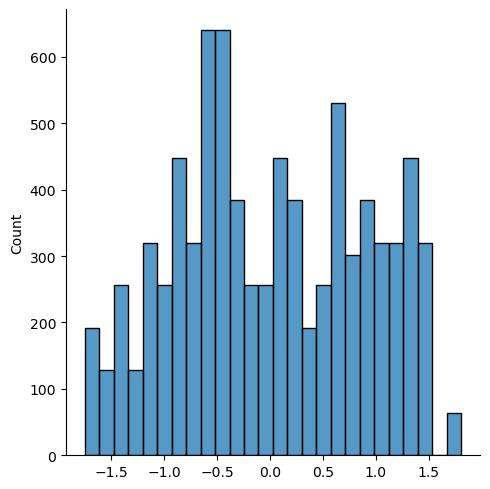

In [14]:
sns.displot(out['z_mu'].reshape(-1).detach().cpu())

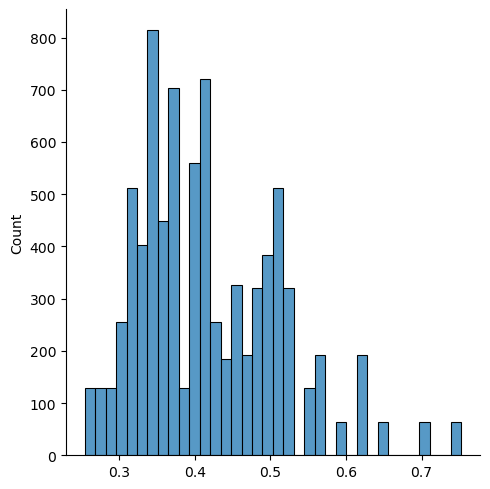

In [15]:
sns.displot(out['z_logvar'].exp().reshape(-1).detach().cpu())

In [16]:
len(loader.train_loader)

7

In [17]:
import seaborn as sns

In [18]:
trainer.dev_metrics

{0: {'train': {'loss': 2.1596120595932007,
   'mse': 0.8108110427856445,
   'rmse': 0.9004504680633545,
   'mae': 0.6150781512260437,
   'r2': 0.7880117893218994},
  'val': {'loss': 2.020714282989502,
   'mse': 0.7686552405357361,
   'rmse': 0.8767298460006714,
   'mae': 0.5984111428260803,
   'r2': 0.7978737354278564}},
 1: {'train': {'loss': 1.976333601134164,
   'mse': 0.7510083317756653,
   'rmse': 0.8666073679924011,
   'mae': 0.589983344078064,
   'r2': 0.8036473393440247},
  'val': {'loss': 1.936625361442566,
   'mse': 0.751632571220398,
   'rmse': 0.8669674396514893,
   'mae': 0.5911926031112671,
   'r2': 0.8023500442504883}},
 2: {'train': {'loss': 1.9140508345195226,
   'mse': 0.7415280938148499,
   'rmse': 0.8611202836036682,
   'mae': 0.5859158635139465,
   'r2': 0.8061259984970093},
  'val': {'loss': 1.8799871802330017,
   'mse': 0.7462054491043091,
   'rmse': 0.8638318181037903,
   'mae': 0.5892844200134277,
   'r2': 0.8037771582603455}},
 3: {'train': {'loss': 1.86384652